<a href="https://colab.research.google.com/github/YABIGAIL23/Simulaci-n-II/blob/main/29_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Método de Nelder-Mead

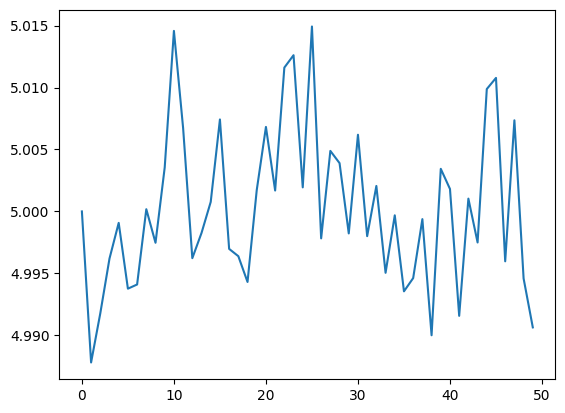

In [ ]:
from random import gauss
from math import sqrt
import numpy as np
import matplotlib.pyplot as plt

def genera(x0, u, o, c, delta, n):
  oo = sqrt(delta)
  l = np.zeros(n)
  l[0] = x0
  for i in range(n-1):
    x = l[i]
    t = 0
    while t<1:
      w = oo*gauss(0,1)
      x += c*(u-x)*delta+o*w
      t +=delta
    l[i+1]=x
  return l

c = 0.8
u = 5
o = 0.01
x0 = u
delta = 0.001
n = 50

l = genera(x0, u, o, c, delta, n)

plt.plot(l)
plt.show ()

In [ ]:
from random import gauss, seed
from math import sqrt, log
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.optimize import minimize

def L(x,l, delta, ns):
  seed(43)
  u=x[0]
  o=x[1]
  c=x[2]
  oo=sqrt(delta)
  n = len(l)
  suma=0
  for i in range(n-1):
    val_sim=np.zeros(ns)
    for j in range(ns):
      sim_x = l[i]
      t=0
      while t<1:
        w=oo*gauss(0,1)
        sim_x += c*(u-sim_x)*delta+o*w
        t+=delta
      val_sim[j]=sim_x
    pdf=gaussian_kde(val_sim)
    valor = pdf(l[i+1])[0]
    if valor < 1e-200:
      valor = 1e-200
    suma = suma + log(valor)
  print("%8.5f"%u,"%8.5f"%o,"%8.5f"%c,"%8.5f"%(suma))
  return -suma

x0=np.array([4.7,0.005,-0.7])
delta=0.1
ns=100

res=minimize(L, x0, args=(l, delta, ns), method='Nelder-Mead')
print(res)

 4.70000  0.00500 -0.70000 -22565.33391
 4.93500  0.00500 -0.70000 -8475.42164
 4.70000  0.00525 -0.70000 -22565.33391
 4.70000  0.00500 -0.73500 -22565.33391
 4.85667  0.00517 -0.66500 -22533.40778
 4.96111  0.00486 -0.67667 -2226.59426
 5.09167  0.00467 -0.66500 -17837.19256
 5.13519  0.00502 -0.66111 -22513.68547
 5.16420  0.00475 -0.69352 -22565.33391
 4.93355  0.00506 -0.67213 -7845.28255
 4.75126  0.00493 -0.70475 -22565.33391
 5.03920  0.00500 -0.67202 -1827.38447
 5.02091  0.00495 -0.64721 -220.90559
 5.06386  0.00492 -0.62082 -5868.70424
 5.08060  0.00481 -0.65847 -12856.73580
 4.97031  0.00500 -0.66871 -964.41065
 5.05917  0.00510 -0.64863 -4853.02766
 4.98563  0.00492 -0.66966 -125.83640
 4.94536  0.00492 -0.65170 -4772.71963
 5.01574  0.00498 -0.66694 -51.41220
 5.04454  0.00490 -0.65383 -2580.34396
 4.98887  0.00497 -0.66499 -23.23978
 4.97258  0.00497 -0.68718 -864.15889
 5.00883  0.00495 -0.65720 82.51195
 5.02333  0.00501 -0.65643 -331.90225
 4.99505  0.00494 -0.66635 7

In [ ]:
!pip install jit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.2/229.2 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for jit: filename=jit-0.2.7-py3-none-any.whl size=251949 sha256=5c1e48606cecd3f6e1ecd106063f82f33cd54f463bcbd3c5abeda39785db2c5d
  Stored in directory: /root/.cache/pip/wheels/37/b5/46/a49b68cb5e4dcc3f6ad0adabbe65537c67a5ad4cc5b42ef801
Successfully built jit


In [ ]:
from random import gauss, seed
from math import sqrt, log, pi, exp
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.optimize import minimize
from numba import jit

@jit(nopython=True)
def K(s):
  return(1/sqrt(2*pi))*exp(-s**2/2)

@jit(nopython=True)
def pdf(x,l):
  n=len(l)
  h = 1.06*np.std(l)/(n**0.2)
  suma = 0
  for i in range(n):
    suma = suma + K((x-l[i])/h)
  return suma/n

@jit(nopython=True)
def L(x,l, delta, ns):
  seed(43)
  u=x[0]
  o=x[1]
  c=x[2]
  oo=sqrt(delta)
  n = len(l)
  suma=0
  for i in range(n-1):
    val_sim=np.zeros(ns)
    for j in range(ns):
      sim_x = l[i]
      t=0
      while t<1:
        w=oo*gauss(0,1)
        sim_x += c*(u-sim_x)*delta+o*w
        t+=delta
      val_sim[j]=sim_x
    valor = pdf(l[i+1],val_sim)
    if valor < 1e-200:
      valor = 1e-200
    suma = suma + log(valor)
  # print("%8.5f"%u,"%8.5f"%o,"%8.5f"%c,"%8.5f"%(suma)) # Removed this line
  return -suma

x0=np.array([4.7,0.005,-0.7])
delta=0.1
ns=100

res=minimize(L, x0, args=(l, delta, ns), method='Nelder-Mead')
print(res)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 91.16560771571062
             x: [ 5.015e+00  4.498e-01 -4.850e-01]
           nit: 197
          nfev: 359
 final_simplex: (array([[ 5.015e+00,  4.498e-01, -4.850e-01],
                       [ 5.015e+00,  4.498e-01, -4.851e-01],
                       [ 5.015e+00,  4.497e-01, -4.850e-01],
                       [ 5.015e+00,  4.497e-01, -4.851e-01]]), array([ 9.117e+01,  9.117e+01,  9.117e+01,  9.117e+01]))
